In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import plotnine as p9

In [2]:
import pandas as pd
import numpy as np
from plotnine import *
from sklearn.linear_model import LinearRegression

BYTES_FLOAT = 4
BYTES_INDEX = 4

# ===============================
# LOAD
# ===============================

sw = pd.read_csv("./statistics/sliding_windows.csv")
ad = pd.read_csv("./statistics/attention_distillation.csv")
ci = pd.read_csv("./statistics/chefer_importance.csv")

# ===============================
# STANDARDIZE PARAM COLUMN
# ===============================

sw["method"] = "Sliding Window"
sw["param"] = "w=" + sw["window_size"].astype(str)

ad["method"] = "Attention Distillation"
ad["param"] = "t=" + ad["threshold"].astype(str)

ci["method"] = "Chefer Importance"
ci["param"] = (
    "nt=" + ci["node_threshold"].astype(str) +
    "_et=" + ci["edge_threshold"].astype(str)
)

# Align columns
common_cols = [
    "dataset", "split", "index",
    "document_length", "token_count",
    "node_count", "node_embedding_dimension",
    "edge_count", "edge_embedding_dimension",
    "method", "param"
]

df = pd.concat([
    sw[common_cols],
    ad[common_cols],
    ci[common_cols]
], ignore_index=True)

# ===============================
# MEMORY COMPUTATION
# ===============================

df["node_memory"] = (
    df["node_count"] *
    df["node_embedding_dimension"] *
    BYTES_FLOAT
)

df["edge_feature_memory"] = (
    df["edge_count"] *
    df["edge_embedding_dimension"] *
    BYTES_FLOAT
)

df["edge_index_memory"] = (
    2 * df["edge_count"] * BYTES_INDEX
)

df["total_bytes"] = (
    df["node_memory"] +
    df["edge_feature_memory"] +
    df["edge_index_memory"]
)

df["total_MB"] = df["total_bytes"] / (1024**2)

df["memory_per_token"] = df["total_bytes"] / df["token_count"]

df["edge_node_ratio"] = df["edge_count"] / df["node_count"]

df["graph_density"] = df["edge_count"] / (df["node_count"] ** 2)


In [3]:
df.isna().sum()

dataset                     0
split                       0
index                       0
document_length             0
token_count                 0
node_count                  0
node_embedding_dimension    0
edge_count                  0
edge_embedding_dimension    0
method                      0
param                       0
node_memory                 0
edge_feature_memory         0
edge_index_memory           0
total_bytes                 0
total_MB                    0
memory_per_token            0
edge_node_ratio             0
graph_density               0
dtype: int64

In [27]:
df = pd.concat([
  df[df['param'].isin([f'nt={x}_et={x}' for x in [0.5, 0.6, 0.7, 0.8, 0.9, 0.95]])],
  df[df['param'].isin([f't={x}' for x in [0.6, 0.7, 0.8, 0.9, 0.95, 0.99]])],
  df[df['param'].isin([f'w={x}' for x in [2, 3, 4, 5]])],
])

# Total Memory vs. Document Length

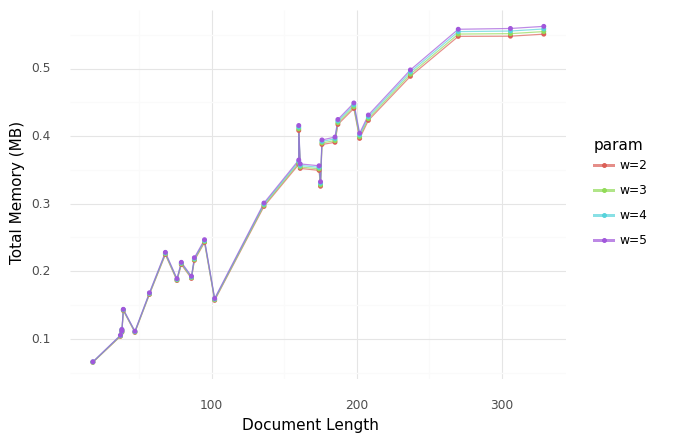

<ggplot: (335131889)>

In [31]:
(
    ggplot(df[df['method'] == 'Sliding Window'], aes(x="document_length", y="total_MB",
                   color="param"))
    + geom_line(alpha=0.7)
    + geom_point(size=1)
    + labs(
        x="Document Length",
        y="Total Memory (MB)"
    )
    + theme_minimal()
)

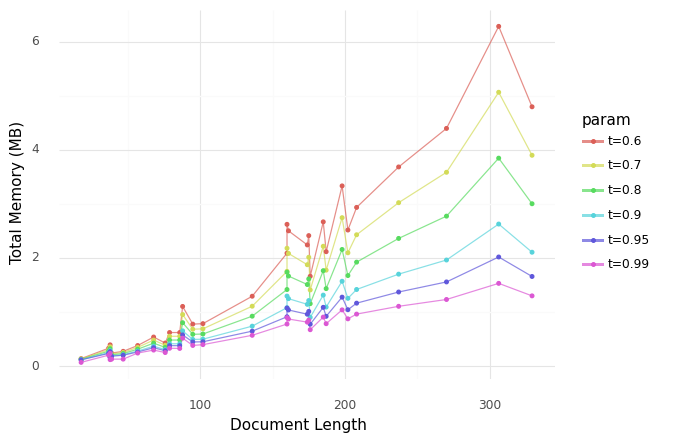

<ggplot: (335034423)>

In [32]:
(
    ggplot(df[df['method'] == 'Attention Distillation'], aes(x="document_length", y="total_MB",
                   color="param"))
    + geom_line(alpha=0.7)
    + geom_point(size=1)
    + labs(
        x="Document Length",
        y="Total Memory (MB)"
    )
    + theme_minimal()
)

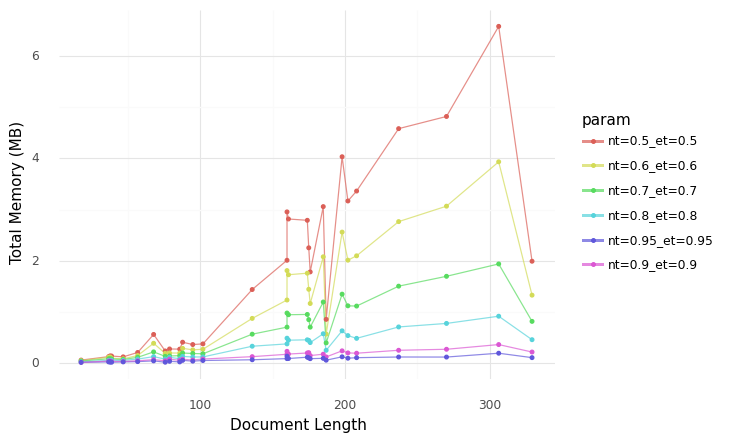

<ggplot: (334283353)>

In [33]:
(
    ggplot(df[df['method'] == 'Chefer Importance'], aes(x="document_length", y="total_MB",
                   color="param"))
    + geom_line(alpha=0.7)
    + geom_point(size=1)
    + labs(
        x="Document Length",
        y="Total Memory (MB)"
    )
    + theme_minimal()
)

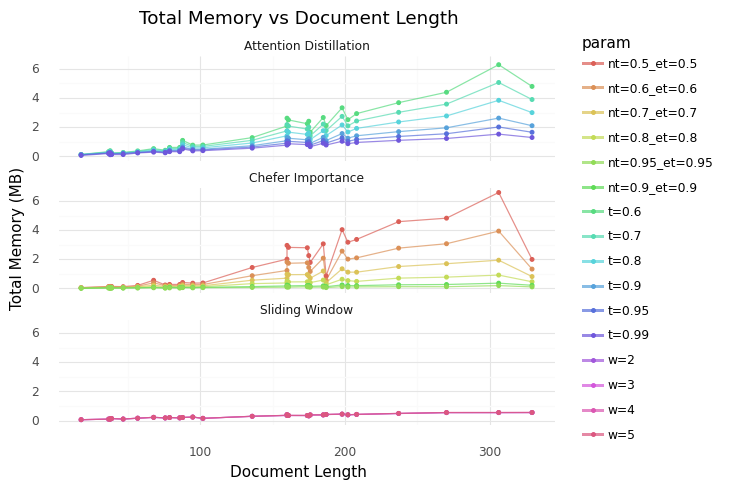

<ggplot: (335431437)>

In [28]:
(
    ggplot(df, aes(x="document_length", y="total_MB",
                   color="param"))
    + geom_line(alpha=0.7)
    + geom_point(size=1)
    + facet_wrap(facets = '~ method', ncol = 1)
    + labs(
        title="Total Memory vs Document Length",
        x="Document Length",
        y="Total Memory (MB)"
    )
    + theme_minimal()
)

# Memory Per Token vs Document Length

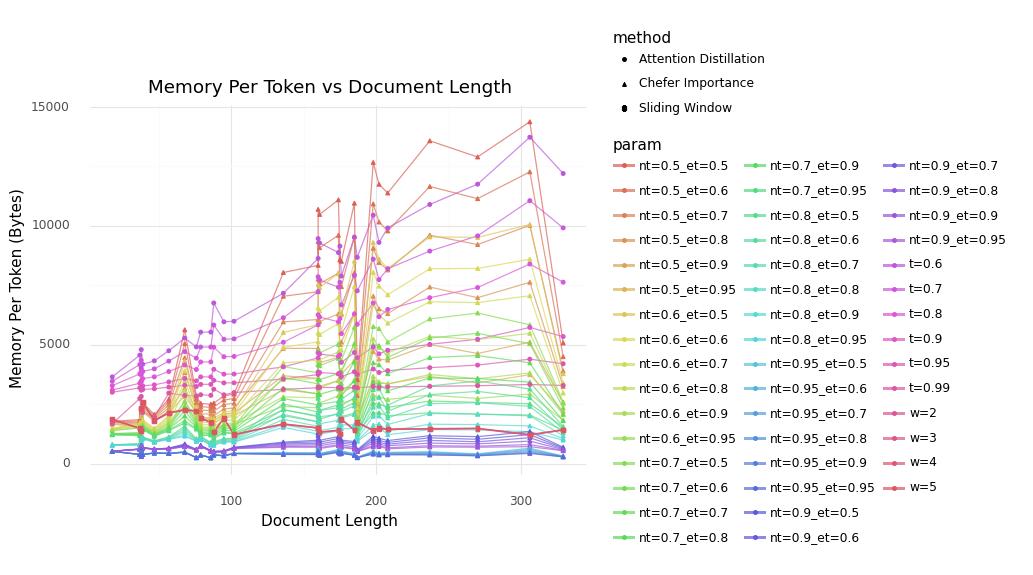

<ggplot: (333839505)>

In [5]:
(
    ggplot(df, aes(x="document_length", y="memory_per_token",
                   shape="method", color="param"))
    + geom_line(alpha=0.7)
    + geom_point(size=1)
    + labs(
        title="Memory Per Token vs Document Length",
        x="Document Length",
        y="Memory Per Token (Bytes)"
    )
    + theme_minimal()
)

# Edge Count vs Document Length (Log–Log)

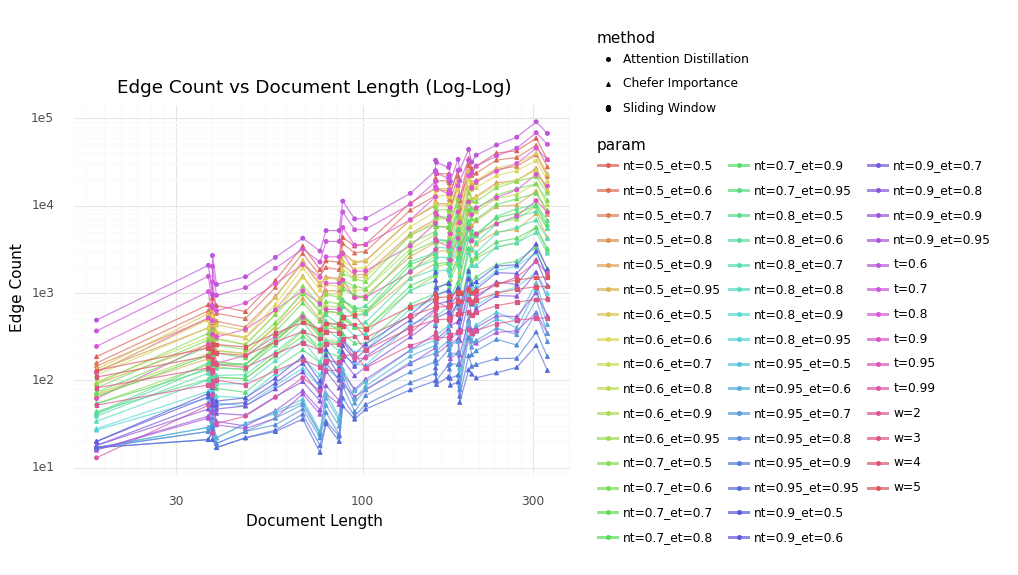

<ggplot: (278625013)>

In [6]:
(
    ggplot(df, aes(x="document_length", y="edge_count",
                   shape="method", color="param"))
    + geom_line(alpha=0.7)
    + geom_point(size=1)
    + scale_x_log10()
    + scale_y_log10()
    + labs(
        title="Edge Count vs Document Length (Log-Log)",
        x="Document Length",
        y="Edge Count"
    )
    + theme_minimal()
)

# Edge-to-Node Ratio

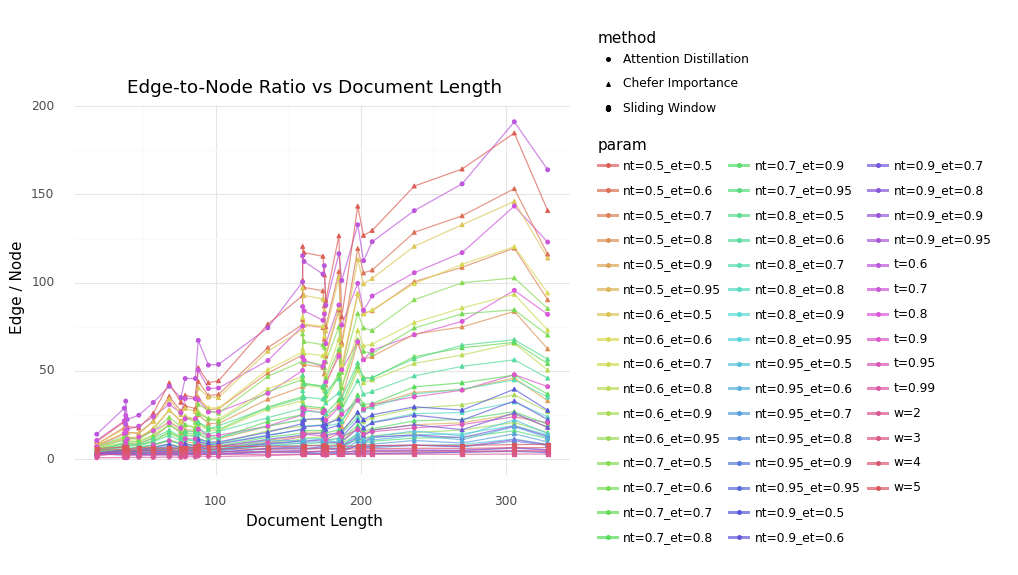

<ggplot: (334217207)>

In [7]:
(
    ggplot(df, aes(x="document_length", y="edge_node_ratio",
                   shape="method", color="param"))
    + geom_line(alpha=0.7)
    + geom_point(size=1)
    + labs(
        title="Edge-to-Node Ratio vs Document Length",
        x="Document Length",
        y="Edge / Node"
    )
    + theme_minimal()
)

# Graph Density vs Document Length

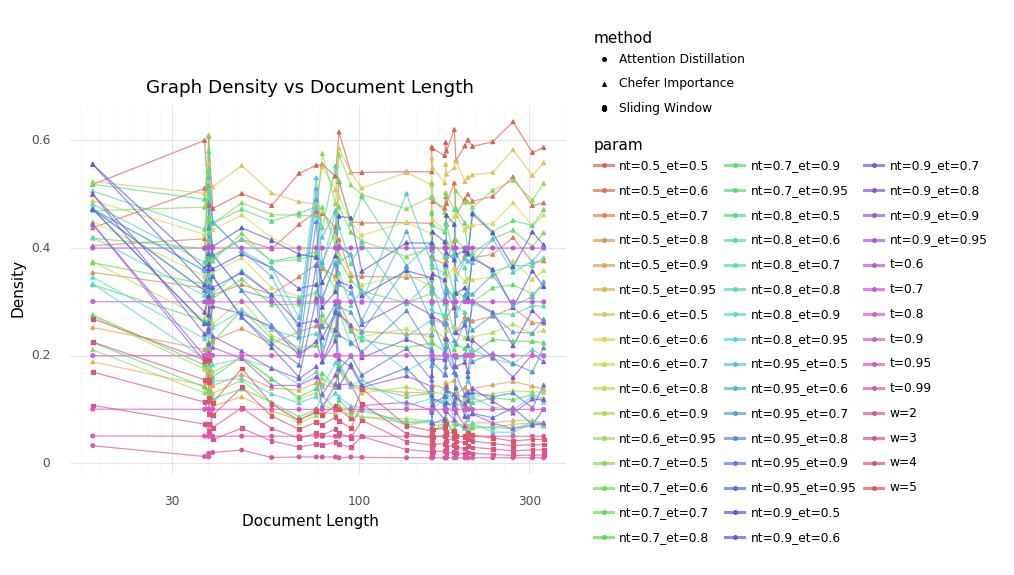

<ggplot: (334387149)>

In [8]:
(
    ggplot(df, aes(x="document_length", y="graph_density",
                   shape="method", color="param"))
    + geom_line(alpha=0.7)
    + geom_point(size=1)
    + scale_x_log10()
    + labs(
        title="Graph Density vs Document Length",
        x="Document Length",
        y="Density"
    )
    + theme_minimal()
)

In [9]:
def compute_slope(data, x_col, y_col):
    slopes = []

    for (method, param), group in data.groupby(["method", "param"]):
        if len(group) < 2:
            continue

        X = np.log10(group[x_col]).values.reshape(-1, 1)
        y = np.log10(group[y_col]).values

        model = LinearRegression().fit(X, y)
        slope = model.coef_[0]

        slopes.append({
            "method": method,
            "param": param,
            "metric": y_col,
            "scaling_exponent": slope
        })

    return pd.DataFrame(slopes)


memory_slopes = compute_slope(df, "document_length", "total_MB")
edge_slopes = compute_slope(df, "document_length", "edge_count")

scaling_table = pd.concat([memory_slopes, edge_slopes], ignore_index=True)

scaling_table.sort_values(["metric", "method"])

,method,param,metric,scaling_exponent
46,Attention Distillation,t=0.6,edge_count,1.894375
47,Attention Distillation,t=0.7,edge_count,1.894271
48,Attention Distillation,t=0.8,edge_count,1.894247
49,Attention Distillation,t=0.9,edge_count,1.893483
50,Attention Distillation,t=0.95,edge_count,1.891910
...,...,...,...,...
41,Chefer Importance,nt=0.9_et=0.95,total_MB,0.988579
42,Sliding Window,w=2,total_MB,0.772011
43,Sliding Window,w=3,total_MB,0.772674
44,Sliding Window,w=4,total_MB,0.773536


In [10]:
from sklearn.linear_model import LinearRegression
import numpy as np

def compute_slope(data, x_col, y_col, metric_name):
    slopes = []

    for (method, param), group in data.groupby(["method", "param"]):
        if len(group) < 2:
            continue

        group = group.sort_values(x_col)

        X = np.log10(group[x_col].values).reshape(-1, 1)
        y = np.log10(group[y_col].values)

        model = LinearRegression().fit(X, y)
        slope = model.coef_[0]

        slopes.append({
            "method": method,
            "param": param,
            "metric": metric_name,
            "scaling_exponent": slope
        })

    return pd.DataFrame(slopes)


memory_slopes = compute_slope(df, "document_length", "total_MB", "Total Memory")
edge_slopes = compute_slope(df, "document_length", "edge_count", "Edge Count")

scaling_df = pd.concat([memory_slopes, edge_slopes], ignore_index=True)


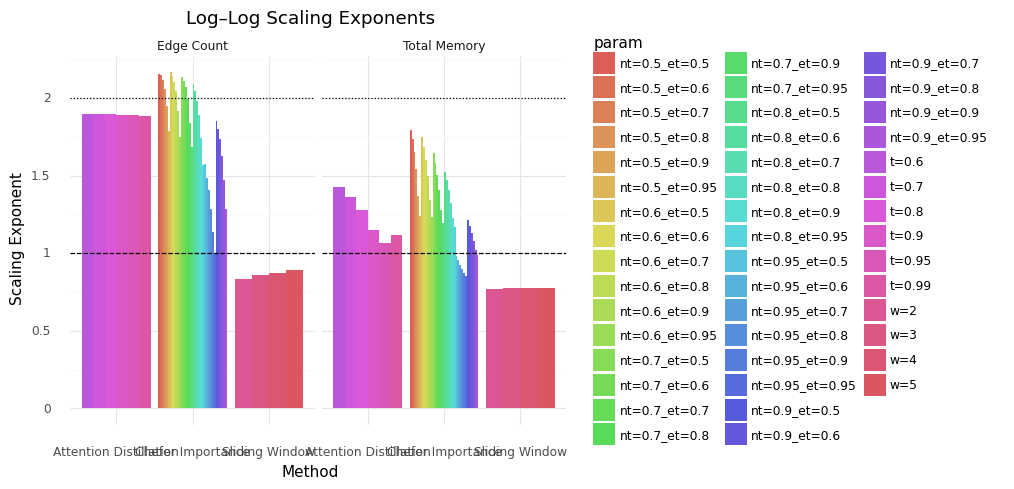

<ggplot: (334581514)>

In [11]:
(
    ggplot(scaling_df,
           aes(x="method",
               y="scaling_exponent",
               fill="param"))
    + geom_bar(stat="identity", position="dodge")
    + geom_hline(yintercept=1, linetype="dashed")  # linear reference
    + geom_hline(yintercept=2, linetype="dotted")  # quadratic reference
    + facet_wrap("~metric")
    + labs(
        title="Log–Log Scaling Exponents",
        x="Method",
        y="Scaling Exponent"
    )
    + theme_minimal()
)


In [12]:
# p9.ggplot(
#     plot_df,
#     p9.aes(x = 'label', y = 'proportion', fill = 'split')
#   ) + \
#     p9.geom_bar(stat = 'identity', position = p9.position_dodge2(), colour = '#000000') + \
#     p9.geom_text(p9.aes(y = f'proportion + {annotation_theme[0]}', label = 'proportion_label'), position = p9.position_dodge2(width = .9), size = annotation_theme[1], angle = annotation_theme[2]) + \
#     p9.ylab('Proportion (%)') + \
#     p9.xlab('Label') + \
#     p9.labs(fill = 'Split') + \
#     p9.theme_bw() + \
#     p9.scale_fill_manual(values = ['#ef8a62', '#67a9cf', '#ffd760', '#f7f7f7']) + \
#     p9.theme(
#       legend_position = 'top',
#       legend_background = p9.element_rect(color = '#000000', fill = '#ebebeb'),
#       legend_box_margin = 0,
#       figure_size = (12, 8),
#       text = p9.element_text(size = 25, family = 'serif'),
#       axis_text = p9.element_text(size = 22),
#       axis_title = p9.element_text(weight = 'bold'),
#       legend_title = p9.element_text(weight = 'bold'),
#     )